# Bias, Variance, Regularization, and Learning Curves

This notebook is executable from the chapter directory.

## Learning goals

Use polynomial models to visualize underfitting and overfitting, create learning curves, and inspect L1/L2 regularization on the incident dataset.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LogisticRegression, Ridge
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

REPO = Path.cwd().parents[1]
sys.path.insert(0, str(REPO / "src"))

from ml_foundations.data import FEATURE_COLUMNS, temporal_split

ASSETS = Path.cwd() / "assets"
ASSETS.mkdir(exist_ok=True)
rng = np.random.default_rng(11)

## Polynomial complexity and validation error

In [2]:
x = np.linspace(-3.0, 3.0, 220)
y = 0.7 * x ** 3 - 1.4 * x + rng.normal(0, 2.2, len(x))
order = rng.permutation(len(x))
train_index, validation_index = order[:150], order[150:]
X_train, y_train = x[train_index, None], y[train_index]
X_val, y_val = x[validation_index, None], y[validation_index]

degrees = list(range(1, 16))
training_error = []
validation_error = []
for degree in degrees:
    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=0.05),
    )
    model.fit(X_train, y_train)
    training_error.append(mean_squared_error(y_train, model.predict(X_train)))
    validation_error.append(mean_squared_error(y_val, model.predict(X_val)))

best_degree = degrees[int(np.argmin(validation_error))]
print("Best validation degree:", best_degree)

Best validation degree: 4


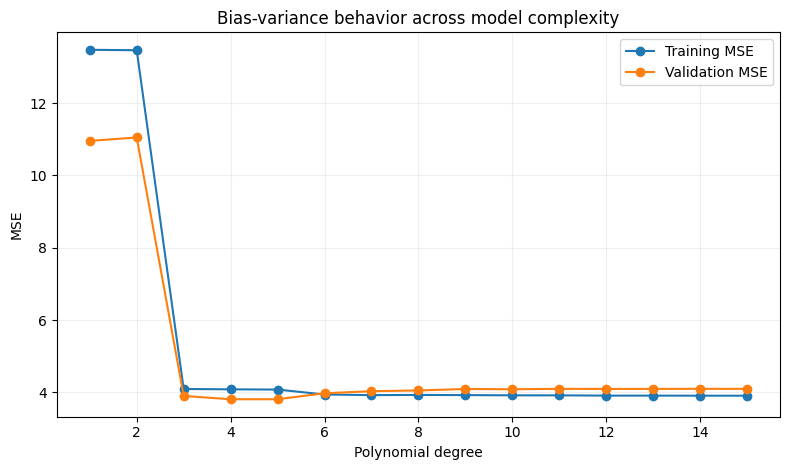

In [3]:
plt.figure(figsize=(8, 4.8))
plt.plot(degrees, training_error, marker="o", label="Training MSE")
plt.plot(degrees, validation_error, marker="o", label="Validation MSE")
plt.xlabel("Polynomial degree")
plt.ylabel("MSE")
plt.title("Bias-variance behavior across model complexity")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "bias_variance_degree.png", dpi=160)
plt.show()

## Learning curve

Use increasing amounts of training data while preserving a fixed validation set.

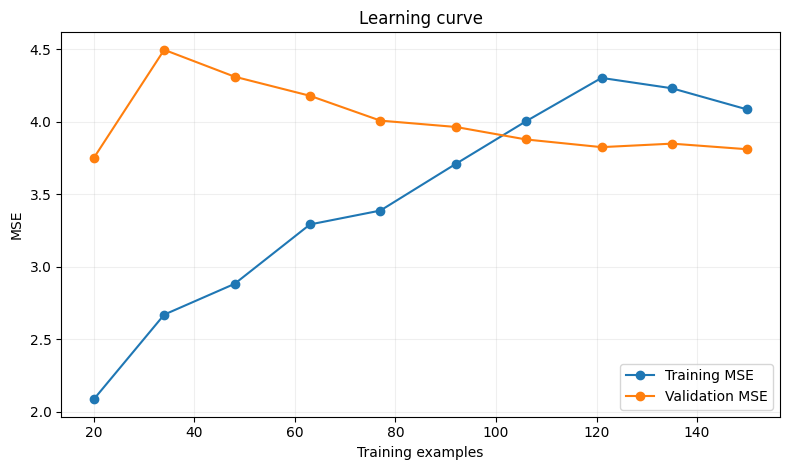

In [4]:
sizes = np.linspace(20, len(X_train), 10, dtype=int)
train_curve = []
validation_curve = []
for size in sizes:
    model = make_pipeline(
        PolynomialFeatures(degree=best_degree, include_bias=False),
        StandardScaler(),
        Ridge(alpha=0.05),
    )
    model.fit(X_train[:size], y_train[:size])
    train_curve.append(mean_squared_error(y_train[:size], model.predict(X_train[:size])))
    validation_curve.append(mean_squared_error(y_val, model.predict(X_val)))

plt.figure(figsize=(8, 4.8))
plt.plot(sizes, train_curve, marker="o", label="Training MSE")
plt.plot(sizes, validation_curve, marker="o", label="Validation MSE")
plt.xlabel("Training examples")
plt.ylabel("MSE")
plt.title("Learning curve")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "learning_curve.png", dpi=160)
plt.show()

## L1 and L2 regularization path for incident classification

Smaller `C` means stronger regularization in scikit-learn logistic regression.

In [5]:
incidents = pd.read_csv(REPO / "data/incident_priority_synthetic.csv", parse_dates=["timestamp"])
train, validation, test = temporal_split(incidents)
scaler = StandardScaler().fit(train[FEATURE_COLUMNS])
X_train_inc = scaler.transform(train[FEATURE_COLUMNS])
y_train_inc = train["is_p1"].to_numpy()

C_values = np.logspace(-3, 2, 14)
l1_norms = []
l2_norms = []
l1_nonzero = []

for C in C_values:
    l1_model = LogisticRegression(
        C=C,
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
    ).fit(X_train_inc, y_train_inc)
    l2_model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
    ).fit(X_train_inc, y_train_inc)
    l1_norms.append(np.linalg.norm(l1_model.coef_[0], ord=1))
    l2_norms.append(np.linalg.norm(l2_model.coef_[0], ord=2))
    l1_nonzero.append(np.count_nonzero(np.abs(l1_model.coef_[0]) > 1e-8))

regularization_table = pd.DataFrame(
    {"C": C_values, "L1 coefficient norm": l1_norms, "L2 coefficient norm": l2_norms, "L1 nonzero": l1_nonzero}
)
regularization_table.head()

/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/pyvenv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(

,C,L1 coefficient norm,L2 coefficient norm,L1 nonzero
0,0.001000,0.000000,0.341654,0
1,0.002424,0.000000,0.551662,0
2,0.005878,0.557503,0.796427,3
3,0.014251,1.484422,1.046233,6
4,0.034551,2.485530,1.265388,7


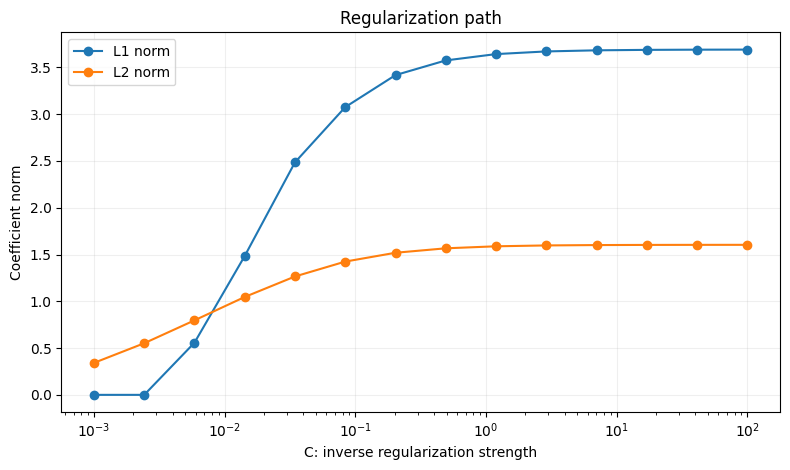

In [6]:
plt.figure(figsize=(8, 4.8))
plt.semilogx(C_values, l1_norms, marker="o", label="L1 norm")
plt.semilogx(C_values, l2_norms, marker="o", label="L2 norm")
plt.xlabel("C: inverse regularization strength")
plt.ylabel("Coefficient norm")
plt.title("Regularization path")
plt.grid(alpha=0.2)
plt.legend()
plt.tight_layout()
plt.savefig(ASSETS / "regularization_path.png", dpi=160)
plt.show()

## Optional sparse-regression comparison

Ridge shrinks coefficients; Lasso can set some to zero. This small example reinforces the difference outside classification.

In [7]:
X_sparse = rng.normal(size=(300, 12))
true_coef = np.array([2.5, 0, 0, -1.7, 0, 0, 0.8, 0, 0, 0, 0, 0])
y_sparse = X_sparse @ true_coef + rng.normal(0, 0.8, 300)

ridge = Ridge(alpha=4.0).fit(X_sparse, y_sparse)
lasso = Lasso(alpha=0.10, max_iter=5000).fit(X_sparse, y_sparse)
print("True: ", np.round(true_coef, 2))
print("Ridge:", np.round(ridge.coef_, 2))
print("Lasso:", np.round(lasso.coef_, 2))

True:  [ 2.5  0.   0.  -1.7  0.   0.   0.8  0.   0.   0.   0.   0. ]
Ridge: [ 2.43 -0.02 -0.02 -1.64 -0.02  0.    0.86 -0.03  0.02 -0.05  0.04 -0.01]
Lasso: [ 2.38 -0.   -0.   -1.55 -0.    0.    0.77 -0.    0.   -0.    0.   -0.  ]


## Interview reflection

Explain why more data can reduce variance but cannot repair target leakage, and why coefficient sparsity does not prove a feature is unimportant or causal.